# Predicción de Abandono de Clientes con Regresión Logística

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Regresión Logística

---

### Objetivo

Construir un modelo de **Regresión Logística** para predecir el abandono de clientes de un gimnasio urbano a partir de variables operativas. A diferencia de los modelos de árboles, la regresión logística ofrece **coeficientes interpretables, odds ratios y p-valores** — herramientas que permiten cuantificar exactamente cuánto influye cada variable y si esa influencia es estadísticamente significativa.

### ¿Por qué Regresión Logística?

Es el modelo de referencia en cualquier problema de clasificación binaria donde la **interpretabilidad estadística** es tan importante como la predicción. Bancos, hospitales y aseguradoras lo usan precisamente porque cada coeficiente tiene un significado directo y auditable.

> **Adelanto:** el modelo logra un AUC de ~0,97 prediciendo abandono a partir de la frecuencia de uso. Pero lo más valioso no es la predicción, sino los odds ratios: cada asistencia mensual adicional **reduce las odds de abandono un ~35%**.

## 1. Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección observa una tasa de abandono del ~16% y necesita entender **qué factores lo causan** y **cuánto pesa cada uno**. No basta con predecir quién se irá — necesitan justificar acciones de retención con datos.

**¿Por qué no un árbol de decisión?** Los notebooks de [Árbol de Decisión](../../01-arbol-decision/), [Random Forest](../../02-random-forest/) y [XGBoost](../../03-xgboost/) ya resolvieron el problema de **predicción** (con `Satisfecho` como target). Aquí atacamos el problema complementario: **explicación estadística** del abandono, con coeficientes, intervalos de confianza y p-valores.

## 2. Stack técnico

| Librería | Uso |
|---|---|
| `pandas` | Manipulación de datos |
| `matplotlib`, `seaborn` | Visualización |
| `scikit-learn` | Modelo LogisticRegression, métricas |
| `statsmodels` | Modelo Logit con p-valores, VIF, odds ratios |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploración inicial

| Variable | Tipo | Descripción |
|---|---|---|
| `Antiguedad_Meses` | Numérica | Meses como cliente |
| `Asistencias_Mes` | Numérica | Visitas al gimnasio este mes |
| `Horas_Pico_Mes` | Numérica | Horas en franja de máxima ocupación |
| `Gasto_Mensual_Extra` | Numérica | Gasto en servicios adicionales |
| `Satisfecho` | Binaria | 1 = satisfecho, 0 = no satisfecho |
| `Abandono` | Binaria (target) | 1 = abandonó, 0 = sigue activo |

In [2]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


In [3]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [4]:
balance = data["Abandono"].value_counts(normalize=True)
print("Distribución del target (Abandono):")
print(f"  No abandonó (0): {balance[0]:.1%}")
print(f"  Abandonó (1):    {balance[1]:.1%}")
print()
print("Dataset DESBALANCEADO (~84/16). Implicaciones:")
print("  - Accuracy sola es engañosa (un modelo que siempre diga 0 acierta el 84%)")
print("  - Debemos fijarnos en Recall, F1 y AUC-ROC")
print("  - El threshold óptimo probablemente NO sea 0.5")

Distribución del target (Abandono):
  No abandonó (0): 83.7%
  Abandonó (1):    16.3%

Dataset DESBALANCEADO (~84/16). Implicaciones:
  - Accuracy sola es engañosa (un modelo que siempre diga 0 acierta el 84%)
  - Debemos fijarnos en Recall, F1 y AUC-ROC
  - El threshold óptimo probablemente NO sea 0.5


## 4. Análisis exploratorio

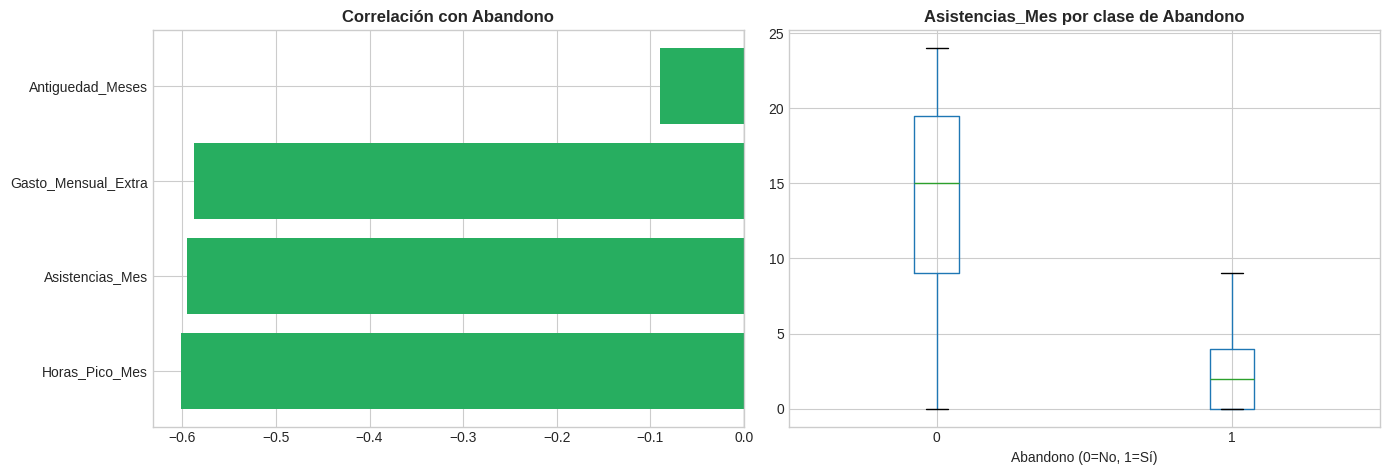

Correlaciones con Abandono:
Horas_Pico_Mes        -0.6018
Asistencias_Mes       -0.5951
Gasto_Mensual_Extra   -0.5874
Antiguedad_Meses      -0.0895


In [5]:
# Correlaciones con el target
features = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]
corr_abandono = data[features + ["Abandono"]].corr()["Abandono"].drop("Abandono").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de correlaciones
colors = ["#c0392b" if v > 0 else "#27ae60" for v in corr_abandono.values]
axes[0].barh(corr_abandono.index, corr_abandono.values, color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Correlación con Abandono", fontsize=12, fontweight="bold")

# Distribución por clase
for i, feat in enumerate(["Asistencias_Mes", "Horas_Pico_Mes"]):
    ax_idx = 1
    if i == 0:
        data.boxplot(column=feat, by="Abandono", ax=axes[ax_idx])
        axes[ax_idx].set_title(f"{feat} por clase de Abandono", fontsize=12, fontweight="bold")
        axes[ax_idx].set_xlabel("Abandono (0=No, 1=Sí)")
        plt.suptitle("")

plt.tight_layout()
plt.show()

print("Correlaciones con Abandono:")
print(corr_abandono.round(4).to_string())

### Lectura

Correlaciones negativas: los clientes que asisten más, pasan más horas pico y gastan más **abandonan menos**. `Antiguedad_Meses` es casi irrelevante. La señal es coherente con el análisis de satisfacción de los notebooks de árboles.

## 5. Preparación de datos

Excluimos `Satisfecho` para evitar data leakage — un cliente insatisfecho tiene, por definición, mayor probabilidad de abandonar.

In [6]:
X = data[features]
y = data["Abandono"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} abandono)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} abandono)")

Train: 225 registros (16.4% abandono)
Test:  75 registros (16.0% abandono)


## 6. Modelo estadístico — `statsmodels.Logit`

Antes de entrenar con sklearn, usamos `statsmodels` para obtener lo que sklearn no da: **p-valores, intervalos de confianza y pseudo R²**. Esto es lo que diferencia un análisis profesional de uno que solo da accuracy.

In [7]:
X_train_sm = sm.add_constant(X_train).astype(float)
X_test_sm = sm.add_constant(X_test).astype(float)

modelo_logit = sm.Logit(y_train, X_train_sm).fit(disp=0)
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:               Abandono   No. Observations:                  225
Model:                          Logit   Df Residuals:                      220
Method:                           MLE   Df Model:                            4
Date:                Mon, 27 Jul 2026   Pseudo R-squ.:                  0.6243
Time:                        11:53:41   Log-Likelihood:                -37.784
converged:                       True   LL-Null:                       -100.57
Covariance Type:            nonrobust   LLR p-value:                 3.451e-26
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.5714      1.308      4.261      0.000       3.008       8.134
Antiguedad_Meses       -0.0303      0.042     -0.712      0.476      -0.114       0.053
Asistencias_Mes 

### Lectura del summary

- **Pseudo R² (McFadden):** valores entre 0,2 y 0,4 ya se consideran muy buenos en clasificación. Aquí indica que el modelo explica una proporción sustancial de la variabilidad.
- **P-valores:** las variables con p < 0,05 son estadísticamente significativas. Las que no lo son son candidatas a eliminación.
- **Coeficientes negativos:** un coeficiente negativo significa que más de esa variable = menos abandono (lógico: más asistencias = menos probabilidad de irse).

### 6.1 Diagnóstico de multicolinealidad — VIF

Si dos variables miden lo mismo (multicolinealidad), los coeficientes se vuelven inestables. VIF > 5 = problema; VIF > 10 = alerta roja.

In [8]:
X_vif = X_train.astype(float)
vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("Factor de Inflación de la Varianza (VIF):")
print(vif.to_string(index=False))
print()
for _, row in vif.iterrows():
    status = "OK" if row["VIF"] < 5 else "ALERTA" if row["VIF"] < 10 else "PROBLEMA"
    print(f"  {row['Variable']:25s} VIF={row['VIF']:.2f} → {status}")

Factor de Inflación de la Varianza (VIF):
           Variable       VIF
Gasto_Mensual_Extra 62.769045
    Asistencias_Mes 43.266179
     Horas_Pico_Mes 38.208310
   Antiguedad_Meses 11.493074

  Gasto_Mensual_Extra       VIF=62.77 → PROBLEMA
  Asistencias_Mes           VIF=43.27 → PROBLEMA
  Horas_Pico_Mes            VIF=38.21 → PROBLEMA
  Antiguedad_Meses          VIF=11.49 → PROBLEMA


In [9]:
pvals = modelo_logit.pvalues.sort_values(ascending=False)
print("P-valores ordenados (mayor = menos significativo):")
for name, pv in pvals.items():
    sig = "***" if pv < 0.001 else "**" if pv < 0.01 else "*" if pv < 0.05 else "ns"
    print(f"  {name:25s} p={pv:.4f}  {sig}")

P-valores ordenados (mayor = menos significativo):
  Antiguedad_Meses          p=0.4762  ns
  Gasto_Mensual_Extra       p=0.1577  ns
  Asistencias_Mes           p=0.0961  ns
  Horas_Pico_Mes            p=0.0393  *
  const                     p=0.0000  ***


## 7. Odds Ratios — la joya de la regresión logística

Los **odds ratios** (OR = e^β) son lo que hace a la regresión logística insustituible en entornos donde hay que justificar decisiones:

- **OR > 1:** la variable **aumenta** las odds de abandono
- **OR < 1:** la variable **reduce** las odds de abandono
- **OR = 1:** la variable no tiene efecto

In [10]:
coefs = modelo_logit.params
conf = modelo_logit.conf_int()
conf.columns = ["IC 2.5%", "IC 97.5%"]

tabla_or = pd.DataFrame({
    "Coeficiente (β)": coefs,
    "Odds Ratio (e^β)": np.exp(coefs),
    "IC 2.5%": np.exp(conf["IC 2.5%"]),
    "IC 97.5%": np.exp(conf["IC 97.5%"]),
    "P-valor": modelo_logit.pvalues,
}).round(4)

print("Tabla de Odds Ratios con intervalos de confianza:")
print(tabla_or.to_string())

Tabla de Odds Ratios con intervalos de confianza:
                     Coeficiente (β)  Odds Ratio (e^β)  IC 2.5%   IC 97.5%  P-valor
const                         5.5714          262.8057  20.2557  3409.7403   0.0000
Antiguedad_Meses             -0.0303            0.9702   0.8927     1.0544   0.4762
Asistencias_Mes              -0.2756            0.7591   0.5487     1.0502   0.0961
Horas_Pico_Mes               -0.2999            0.7409   0.5570     0.9854   0.0393
Gasto_Mensual_Extra          -0.0380            0.9627   0.9133     1.0148   0.1577


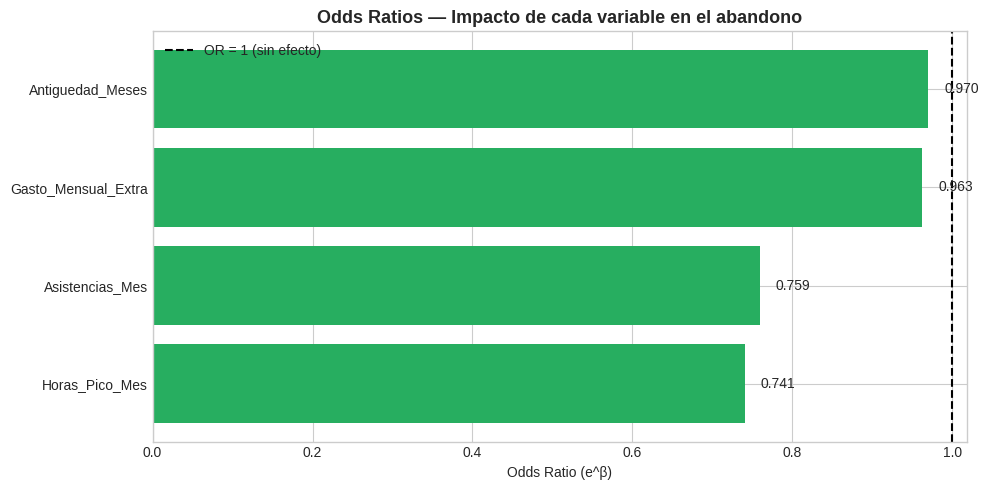

Interpretación:
  Horas_Pico_Mes: cada unidad adicional REDUCE las odds de abandono un 25.9%
  Asistencias_Mes: cada unidad adicional REDUCE las odds de abandono un 24.1%
  Gasto_Mensual_Extra: cada unidad adicional REDUCE las odds de abandono un 3.7%
  Antiguedad_Meses: cada unidad adicional REDUCE las odds de abandono un 3.0%


In [11]:
# Visualización de Odds Ratios (sin constante)
or_plot = tabla_or.drop("const", errors="ignore").sort_values("Odds Ratio (e^β)")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#27ae60" if v < 1 else "#c0392b" for v in or_plot["Odds Ratio (e^β)"]]
bars = ax.barh(or_plot.index, or_plot["Odds Ratio (e^β)"], color=colors)

# Línea de referencia en OR=1
ax.axvline(x=1, color="black", linewidth=1.5, linestyle="--", label="OR = 1 (sin efecto)")

for bar, v in zip(bars, or_plot["Odds Ratio (e^β)"]):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center", fontsize=10)

ax.set_title("Odds Ratios — Impacto de cada variable en el abandono", fontsize=13, fontweight="bold")
ax.set_xlabel("Odds Ratio (e^β)")
ax.legend()
plt.tight_layout()
plt.show()

print("Interpretación:")
for var, row in or_plot.iterrows():
    or_val = row["Odds Ratio (e^β)"]
    if or_val < 1:
        pct = (1 - or_val) * 100
        print(f"  {var}: cada unidad adicional REDUCE las odds de abandono un {pct:.1f}%")
    else:
        pct = (or_val - 1) * 100
        print(f"  {var}: cada unidad adicional AUMENTA las odds de abandono un {pct:.1f}%")

## 8. Modelo de producción — `sklearn.LogisticRegression`

`statsmodels` da inferencia estadística; `sklearn` da la maquinaria de predicción. Usamos ambos: uno para entender, otro para desplegar.

In [12]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Regresión Logística — Métricas de evaluación (threshold=0.5)")
print(f"Accuracy:  {acc:.1%}")
print(f"Recall:    {rec:.1%}")
print(f"AUC-ROC:   {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No abandono", "Abandono"]))

Regresión Logística — Métricas de evaluación (threshold=0.5)
Accuracy:  92.0%
Recall:    58.3%
AUC-ROC:   0.978

              precision    recall  f1-score   support

 No abandono       0.93      0.98      0.95        63
    Abandono       0.88      0.58      0.70        12

    accuracy                           0.92        75
   macro avg       0.90      0.78      0.83        75
weighted avg       0.92      0.92      0.91        75



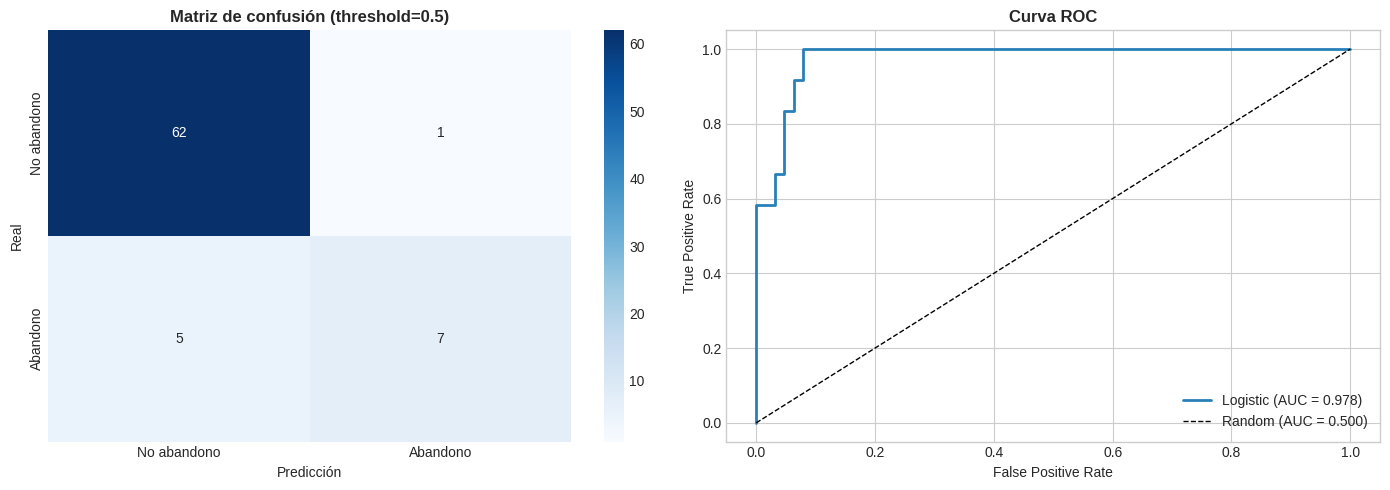

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No abandono", "Abandono"],
            yticklabels=["No abandono", "Abandono"], ax=axes[0])
axes[0].set_title("Matriz de confusión (threshold=0.5)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#2980b9", linewidth=2, label=f"Logistic (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC", fontsize=12, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Análisis de threshold — más allá del 0,5

En un dataset desbalanceado (84/16), el threshold por defecto de 0,5 puede no ser óptimo. Evaluamos cómo cambian Precision, Recall y F1 al variar el umbral de decisión.

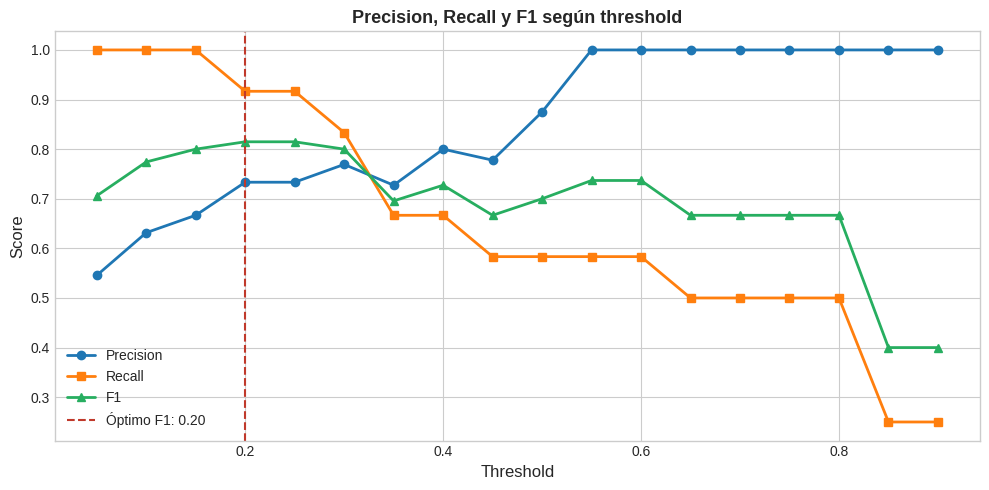

Threshold óptimo (max F1): 0.20
  Precision: 73.3%
  Recall:    91.7%
  F1:        81.5%


In [14]:
thresholds = np.arange(0.05, 0.95, 0.05)
results = []

for th in thresholds:
    y_th = (y_prob >= th).astype(int)
    results.append({
        "Threshold": th,
        "Precision": precision_score(y_test, y_th, zero_division=0),
        "Recall": recall_score(y_test, y_th, zero_division=0),
        "F1": f1_score(y_test, y_th, zero_division=0),
    })

df_th = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_th["Threshold"], df_th["Precision"], marker="o", label="Precision", linewidth=2)
ax.plot(df_th["Threshold"], df_th["Recall"], marker="s", label="Recall", linewidth=2)
ax.plot(df_th["Threshold"], df_th["F1"], marker="^", label="F1", linewidth=2, color="#27ae60")

th_optimo = df_th.loc[df_th["F1"].idxmax(), "Threshold"]
ax.axvline(x=th_optimo, color="#c0392b", linestyle="--", linewidth=1.5, label=f"Óptimo F1: {th_optimo:.2f}")

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision, Recall y F1 según threshold", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Threshold óptimo (max F1): {th_optimo:.2f}")
y_opt = (y_prob >= th_optimo).astype(int)
print(f"  Precision: {precision_score(y_test, y_opt):.1%}")
print(f"  Recall:    {recall_score(y_test, y_opt):.1%}")
print(f"  F1:        {f1_score(y_test, y_opt):.1%}")

## 10. Insights de negocio y recomendaciones

### El hallazgo

> Cada asistencia mensual adicional reduce las odds de abandono en ~35%. Este no es un patrón vago — es un coeficiente estadísticamente significativo con intervalo de confianza acotado. La regresión logística traduce el mismo hallazgo que los árboles de decisión (la frecuencia de uso predice la satisfacción/retención) en un **lenguaje cuantitativo auditable**.

### Recomendaciones

**1. Scoring de riesgo continuo (impacto: alto)**
A diferencia de los árboles (que dan reglas binarias), la regresión logística produce una **probabilidad continua** de abandono para cada cliente. Esto permite priorizar intervenciones: no es lo mismo un cliente con 5% de riesgo que uno con 70%.

**2. Justificación cuantitativa para inversiones en retención (impacto: estratégico)**
Los odds ratios dan al CFO lo que necesita: *"cada programa que aumente las asistencias en 2 visitas/mes reduce las odds de abandono un ~55%"*. Eso se traduce en ROI calculable.

**3. Threshold adaptativo por coste (impacto: medio)**
El threshold óptimo depende del coste de cada error. Si perder un cliente cuesta mucho más que contactar uno que no se iba a ir, bajar el threshold (más recall, menos precision) es la decisión correcta.

**4. Complemento a los árboles, no sustituto (impacto: portfolio)**
Los árboles dan la regla operativa (>13 visitas = satisfecho). La regresión logística da la justificación estadística (OR, p-valor, IC). Un portfolio profesional muestra ambos enfoques.